# SleepAI Notebook 03 : Model Training + MLflow

**Objectif :** Entraîner et tracker les modèles ML avec MLflow

**Partie A — Modèle EEG (classification 5 stades)**
1. Baseline Random Forest
2. Random Forest optimisé (params fixés sur expériences précédentes)
3. Évaluation : rapport de classification + matrice de confusion
4. Importance des features
5. Sauvegarde pipeline `.joblib`

**Partie B — Modèle ECG (détection apnée binaire)**
1. Random Forest avec class_weight balanced
2. Évaluation : AUC-ROC + rapport
3. Sauvegarde pipeline `.joblib`

**MLflow :** Chaque run est tracké — params, métriques, artefacts

**Auteur :** Marine Deldicque  
**Contexte :** AIA Jedha — Bloc 4

## 0. Imports et configuration

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import joblib
warnings.filterwarnings('ignore')

# ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay
)

# MLflow
import mlflow
import mlflow.sklearn

# Chemins
DATA_PROC_EEG = Path('../data/processed/eeg')
DATA_PROC_ECG = Path('../data/processed/ecg')
MODELS_DIR    = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)
Path('../data/figures').mkdir(exist_ok=True)

STAGE_NAMES = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}
PALETTE     = ['#E84855', '#EF8354', '#54C6EB', '#048A81', '#2E4057']

# Configurer MLflow
mlflow.set_tracking_uri('file:../mlruns')
mlflow.set_experiment('SleepAI_v2')

print('Imports OK')
print(f'MLflow tracking URI : {mlflow.get_tracking_uri()}')
print(f'Experiment : SleepAI_v2')

Imports OK
MLflow tracking URI : file:../mlruns
Experiment : SleepAI_v2


## Chargement des données

In [16]:
# === EEG ===
X_train_eeg = np.load(DATA_PROC_EEG / 'X_train.npy')
X_val_eeg   = np.load(DATA_PROC_EEG / 'X_val.npy')
X_test_eeg  = np.load(DATA_PROC_EEG / 'X_test.npy')
y_train_eeg = np.load(DATA_PROC_EEG / 'y_train.npy')
y_val_eeg   = np.load(DATA_PROC_EEG / 'y_val.npy')
y_test_eeg  = np.load(DATA_PROC_EEG / 'y_test.npy')
meta_eeg    = joblib.load(DATA_PROC_EEG / 'metadata.pkl')

# === ECG ===
X_train_ecg = np.load(DATA_PROC_ECG / 'X_train.npy')
X_val_ecg   = np.load(DATA_PROC_ECG / 'X_val.npy')
X_test_ecg  = np.load(DATA_PROC_ECG / 'X_test.npy')
y_train_ecg = np.load(DATA_PROC_ECG / 'y_train.npy')
y_val_ecg   = np.load(DATA_PROC_ECG / 'y_val.npy')
y_test_ecg  = np.load(DATA_PROC_ECG / 'y_test.npy')
meta_ecg    = joblib.load(DATA_PROC_ECG / 'metadata.pkl')

FEATURE_NAMES_EEG = meta_eeg['feature_names']
FEATURE_NAMES_ECG = meta_ecg['feature_names']

print('Données chargées')
print(f'\nEEG  — Train: {X_train_eeg.shape} | Val: {X_val_eeg.shape} | Test: {X_test_eeg.shape}')
print(f'ECG  — Train: {X_train_ecg.shape} | Val: {X_val_ecg.shape} | Test: {X_test_ecg.shape}')

Données chargées

EEG  — Train: (18004, 16) | Val: (3858, 16) | Test: (3859, 16)
ECG  — Train: (10581, 16) | Val: (2267, 16) | Test: (2268, 16)


---
# PARTIE A Modèle EEG (5 stades de sommeil)

## A1. Baseline Random Forest

In [17]:
print('🚀 Run 1 — Baseline Random Forest (EEG)')
print('=' * 50)

params_baseline = {
    'n_estimators' : 100,
    'max_depth'    : None,
    'class_weight' : 'balanced',
    'random_state' : 42,
    'n_jobs'       : -1,
}

with mlflow.start_run(run_name='EEG_RF_baseline') as run:
    
    # Log des paramètres
    mlflow.log_params(params_baseline)
    mlflow.log_param('task', 'sleep_stage_classification')
    mlflow.log_param('n_features', X_train_eeg.shape[1])
    mlflow.log_param('n_train_samples', X_train_eeg.shape[0])
    mlflow.log_param('n_classes', 5)
    
    # Pipeline : StandardScaler + RF
    pipeline_baseline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(**params_baseline))
    ])
    
    # Entraînement
    pipeline_baseline.fit(X_train_eeg, y_train_eeg)
    
    # Évaluation sur val
    y_pred_val = pipeline_baseline.predict(X_val_eeg)
    acc_val    = accuracy_score(y_val_eeg, y_pred_val)
    f1_val     = f1_score(y_val_eeg, y_pred_val, average='weighted')
    
    # Évaluation sur test
    y_pred_test = pipeline_baseline.predict(X_test_eeg)
    acc_test    = accuracy_score(y_test_eeg, y_pred_test)
    f1_test     = f1_score(y_test_eeg, y_pred_test, average='weighted')
    
    # Log des métriques
    mlflow.log_metrics({
        'val_accuracy'  : acc_val,
        'val_f1_weighted': f1_val,
        'test_accuracy' : acc_test,
        'test_f1_weighted': f1_test,
    })
    
    # Log du modèle
    mlflow.sklearn.log_model(pipeline_baseline, 'pipeline_baseline')
    
    run_id_baseline = run.info.run_id
    print(f'Run ID : {run_id_baseline}')

print(f'\n Résultats Baseline :')
print(f'   Val  — Accuracy: {acc_val:.4f} | F1: {f1_val:.4f}')
print(f'   Test — Accuracy: {acc_test:.4f} | F1: {f1_test:.4f}')

🚀 Run 1 — Baseline Random Forest (EEG)


2026/05/07 09:06:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 09:06:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID : 16d57866e6424705a4b2f064252e048a

 Résultats Baseline :
   Val  — Accuracy: 0.8307 | F1: 0.8241
   Test — Accuracy: 0.8316 | F1: 0.8239


## A2. Random Forest optimisé

In [18]:
print(' Run 2 — Random Forest optimisé (EEG)')
print('=' * 50)
print('Paramètres : issus des expériences SleepAI v1')
print()

params_optimized = {
    'n_estimators'     : 200,
    'max_depth'        : 20,
    'min_samples_split': 5,
    'min_samples_leaf' : 2,
    'max_features'     : 'sqrt',
    'class_weight'     : 'balanced',
    'random_state'     : 42,
    'n_jobs'           : -1,
}

with mlflow.start_run(run_name='EEG_RF_optimized') as run:
    
    mlflow.log_params(params_optimized)
    mlflow.log_param('task', 'sleep_stage_classification')
    mlflow.log_param('n_features', X_train_eeg.shape[1])
    mlflow.log_param('n_train_samples', X_train_eeg.shape[0])
    mlflow.log_param('preprocessing', 'StandardScaler + Wake trimming')
    
    pipeline_eeg = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(**params_optimized))
    ])
    
    pipeline_eeg.fit(X_train_eeg, y_train_eeg)
    
    # Évaluation val
    y_pred_val  = pipeline_eeg.predict(X_val_eeg)
    acc_val     = accuracy_score(y_val_eeg, y_pred_val)
    f1_val_w    = f1_score(y_val_eeg, y_pred_val, average='weighted')
    f1_val_mac  = f1_score(y_val_eeg, y_pred_val, average='macro')
    
    # Évaluation test
    y_pred_test = pipeline_eeg.predict(X_test_eeg)
    acc_test    = accuracy_score(y_test_eeg, y_pred_test)
    f1_test_w   = f1_score(y_test_eeg, y_pred_test, average='weighted')
    f1_test_mac = f1_score(y_test_eeg, y_pred_test, average='macro')
    
    # F1 par classe
    f1_per_class = f1_score(y_test_eeg, y_pred_test, average=None)
    for i, f1 in enumerate(f1_per_class):
        mlflow.log_metric(f'test_f1_{STAGE_NAMES[i]}', f1)
    
    mlflow.log_metrics({
        'val_accuracy'      : acc_val,
        'val_f1_weighted'   : f1_val_w,
        'val_f1_macro'      : f1_val_mac,
        'test_accuracy'     : acc_test,
        'test_f1_weighted'  : f1_test_w,
        'test_f1_macro'     : f1_test_mac,
    })
    
    mlflow.sklearn.log_model(pipeline_eeg, 'pipeline_eeg_optimized')
    run_id_eeg = run.info.run_id

print(f'\n Résultats RF Optimisé :')
print(f'   Val  — Accuracy: {acc_val:.4f} | F1 weighted: {f1_val_w:.4f} | F1 macro: {f1_val_mac:.4f}')
print(f'   Test — Accuracy: {acc_test:.4f} | F1 weighted: {f1_test_w:.4f} | F1 macro: {f1_test_mac:.4f}')
print(f'\n   F1 par classe (test) :')
for i, f1 in enumerate(f1_per_class):
    print(f'   {STAGE_NAMES[i]:5s} : {f1:.4f}')

 Run 2 — Random Forest optimisé (EEG)
Paramètres : issus des expériences SleepAI v1



2026/05/07 09:06:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 09:06:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



 Résultats RF Optimisé :
   Val  — Accuracy: 0.8258 | F1 weighted: 0.8224 | F1 macro: 0.7362
   Test — Accuracy: 0.8313 | F1 weighted: 0.8272 | F1 macro: 0.7439

   F1 par classe (test) :
   Wake  : 0.6809
   N1    : 0.4401
   N2    : 0.8974
   N3    : 0.9096
   REM   : 0.7913


## A3. Évaluation détaillée : Matrice de confusion + Rapport

In [19]:
# Rapport de classification
target_names = [STAGE_NAMES[i] for i in range(5)]
report = classification_report(y_test_eeg, y_pred_test, target_names=target_names)
print('=== Rapport de classification — EEG (test set) ===')
print(report)

# Logger le rapport dans MLflow
with mlflow.start_run(run_id=run_id_eeg):
    mlflow.log_text(report, 'classification_report_eeg.txt')

=== Rapport de classification — EEG (test set) ===
              precision    recall  f1-score   support

        Wake       0.65      0.72      0.68       243
          N1       0.56      0.36      0.44       309
          N2       0.91      0.89      0.90      1922
          N3       0.91      0.91      0.91       591
         REM       0.74      0.85      0.79       794

    accuracy                           0.83      3859
   macro avg       0.75      0.75      0.74      3859
weighted avg       0.83      0.83      0.83      3859



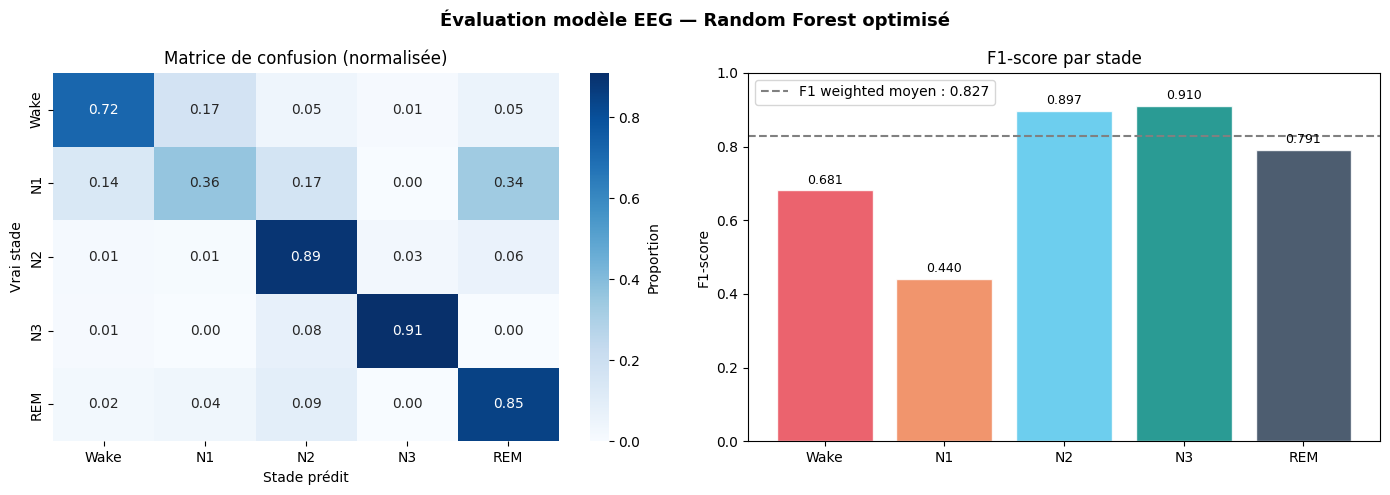

Figure sauvegardée et loggée dans MLflow


In [20]:
# Matrice de confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Évaluation modèle EEG — Random Forest optimisé', fontsize=13, fontweight='bold')

# Matrice de confusion normalisée
cm = confusion_matrix(y_test_eeg, y_pred_test, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            ax=axes[0], cbar_kws={'label': 'Proportion'})
axes[0].set_title('Matrice de confusion (normalisée)')
axes[0].set_ylabel('Vrai stade')
axes[0].set_xlabel('Stade prédit')

# F1 par classe
colors = PALETTE
bars = axes[1].bar(target_names, f1_per_class, color=colors, alpha=0.85, edgecolor='white')
axes[1].axhline(f1_test_w, color='gray', linestyle='--', linewidth=1.5,
                 label=f'F1 weighted moyen : {f1_test_w:.3f}')
axes[1].set_title('F1-score par stade')
axes[1].set_ylabel('F1-score')
axes[1].set_ylim(0, 1)
axes[1].legend()
for bar, f1 in zip(bars, f1_per_class):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.01,
                  f'{f1:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
fig.savefig('../data/figures/eeg_confusion_matrix.png', dpi=150, bbox_inches='tight')

# Logger la figure dans MLflow
with mlflow.start_run(run_id=run_id_eeg):
    mlflow.log_artifact('../data/figures/eeg_confusion_matrix.png')

plt.show()
print('Figure sauvegardée et loggée dans MLflow')

## A4. Importance des features

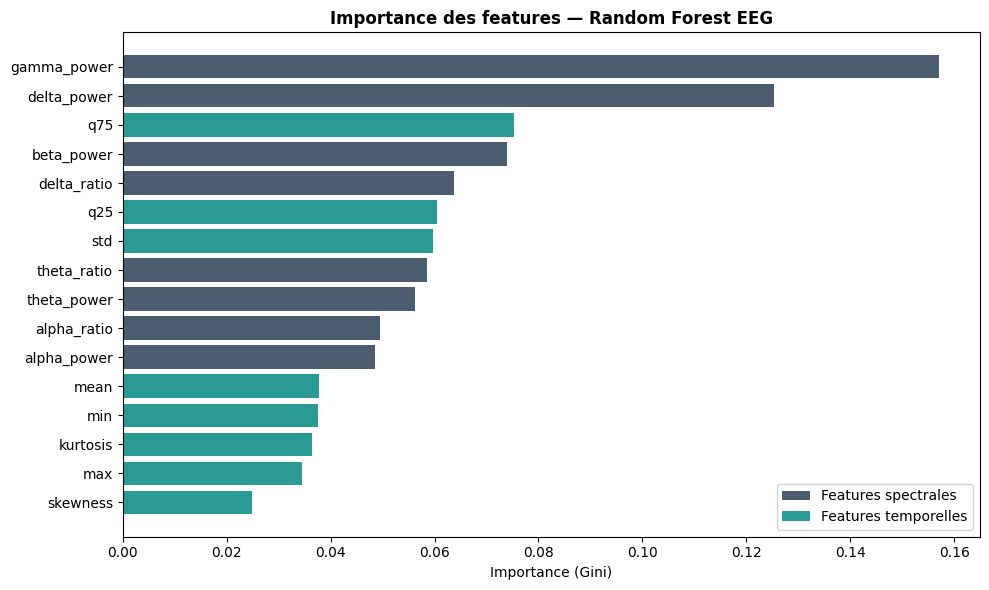

Top 5 features :
   gamma_power          : 0.1571
   delta_power          : 0.1254
   q75                  : 0.0754
   beta_power           : 0.0740
   delta_ratio          : 0.0637


In [21]:
# Feature importance du Random Forest
importances = pipeline_eeg.named_steps['clf'].feature_importances_
indices     = np.argsort(importances)[::-1]

df_importance = pd.DataFrame({
    'feature'   : [FEATURE_NAMES_EEG[i] for i in indices],
    'importance': importances[indices]
})

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = ['#2E4057' if 'power' in f or 'ratio' in f else '#048A81'
               for f in df_importance['feature']]
bars = ax.barh(df_importance['feature'], df_importance['importance'],
                color=colors_imp, alpha=0.85)
ax.set_xlabel('Importance (Gini)')
ax.set_title('Importance des features — Random Forest EEG', fontweight='bold')
ax.invert_yaxis()

# Légende manuelle
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E4057', alpha=0.85, label='Features spectrales'),
    Patch(facecolor='#048A81', alpha=0.85, label='Features temporelles'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
fig.savefig('../data/figures/eeg_feature_importance.png', dpi=150, bbox_inches='tight')

with mlflow.start_run(run_id=run_id_eeg):
    mlflow.log_artifact('../data/figures/eeg_feature_importance.png')

plt.show()

print('Top 5 features :')
for _, row in df_importance.head(5).iterrows():
    print(f'   {row["feature"]:20s} : {row["importance"]:.4f}')

## A5. Sauvegarde pipeline EEG production

In [22]:
# Réentraîner sur train + val pour la production
X_trainval_eeg = np.vstack([X_train_eeg, X_val_eeg])
y_trainval_eeg = np.concatenate([y_train_eeg, y_val_eeg])

print(f'Réentraînement sur train+val : {X_trainval_eeg.shape[0]} échantillons...')

pipeline_eeg_prod = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(**params_optimized))
])
pipeline_eeg_prod.fit(X_trainval_eeg, y_trainval_eeg)

# Vérification sur test
y_pred_final = pipeline_eeg_prod.predict(X_test_eeg)
acc_final    = accuracy_score(y_test_eeg, y_pred_final)
f1_final     = f1_score(y_test_eeg, y_pred_final, average='weighted')

# Sauvegarde
eeg_model_path = MODELS_DIR / 'sleepai_eeg_pipeline.joblib'
joblib.dump(pipeline_eeg_prod, eeg_model_path)

print(f'\n Pipeline EEG sauvegardé : {eeg_model_path}')
print(f'   Test Accuracy final : {acc_final:.4f}')
print(f'   Test F1 weighted    : {f1_final:.4f}')
print(f'   Taille fichier      : {eeg_model_path.stat().st_size / 1024:.0f} Ko')

# Logger dans MLflow
with mlflow.start_run(run_name='EEG_RF_production') as run:
    mlflow.log_params(params_optimized)
    mlflow.log_param('training_set', 'train+val')
    mlflow.log_param('n_samples', X_trainval_eeg.shape[0])
    mlflow.log_metrics({
        'test_accuracy'  : acc_final,
        'test_f1_weighted': f1_final,
    })
    mlflow.sklearn.log_model(pipeline_eeg_prod, 'pipeline_eeg_production')
    mlflow.log_artifact(str(eeg_model_path))
    run_id_prod_eeg = run.info.run_id

print(f'   MLflow run ID : {run_id_prod_eeg}')

Réentraînement sur train+val : 21862 échantillons...


2026/05/07 09:07:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 09:07:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



 Pipeline EEG sauvegardé : ../models/sleepai_eeg_pipeline.joblib
   Test Accuracy final : 0.8344
   Test F1 weighted    : 0.8302
   Taille fichier      : 78900 Ko
   MLflow run ID : ce8888974cd94bed912e56b0db1804bf


---
# PARTIE B Modèle ECG (Détection apnées)

## B1. Random Forest avec class_weight balanced

In [23]:
print('🚀 Run 3 — Random Forest ECG (détection apnée)')
print('=' * 50)
print('Tâche : classification binaire (Normal=0 / Apnée=1)')
print(f'Déséquilibre : {sum(y_train_ecg==1)/len(y_train_ecg)*100:.1f}% apnée')
print()

params_ecg = {
    'n_estimators'     : 200,
    'max_depth'        : 15,
    'min_samples_split': 5,
    'min_samples_leaf' : 2,
    'max_features'     : 'sqrt',
    'class_weight'     : 'balanced',  # Gère le déséquilibre 34/66
    'random_state'     : 42,
    'n_jobs'           : -1,
}

with mlflow.start_run(run_name='ECG_RF_apnea') as run:
    
    mlflow.log_params(params_ecg)
    mlflow.log_param('task', 'apnea_detection')
    mlflow.log_param('n_features', X_train_ecg.shape[1])
    mlflow.log_param('n_train_samples', X_train_ecg.shape[0])
    mlflow.log_param('class_balance', f'{sum(y_train_ecg==1)/len(y_train_ecg)*100:.1f}% apnée')
    
    pipeline_ecg = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(**params_ecg))
    ])
    
    pipeline_ecg.fit(X_train_ecg, y_train_ecg)
    
    # Évaluation val
    y_pred_val_ecg  = pipeline_ecg.predict(X_val_ecg)
    y_proba_val_ecg = pipeline_ecg.predict_proba(X_val_ecg)[:, 1]
    acc_val_ecg     = accuracy_score(y_val_ecg, y_pred_val_ecg)
    f1_val_ecg      = f1_score(y_val_ecg, y_pred_val_ecg, average='weighted')
    auc_val_ecg     = roc_auc_score(y_val_ecg, y_proba_val_ecg)
    
    # Évaluation test
    y_pred_test_ecg  = pipeline_ecg.predict(X_test_ecg)
    y_proba_test_ecg = pipeline_ecg.predict_proba(X_test_ecg)[:, 1]
    acc_test_ecg     = accuracy_score(y_test_ecg, y_pred_test_ecg)
    f1_test_ecg      = f1_score(y_test_ecg, y_pred_test_ecg, average='weighted')
    auc_test_ecg     = roc_auc_score(y_test_ecg, y_proba_test_ecg)
    f1_apnea         = f1_score(y_test_ecg, y_pred_test_ecg, pos_label=1)
    
    mlflow.log_metrics({
        'val_accuracy'  : acc_val_ecg,
        'val_f1'        : f1_val_ecg,
        'val_auc_roc'   : auc_val_ecg,
        'test_accuracy' : acc_test_ecg,
        'test_f1'       : f1_test_ecg,
        'test_auc_roc'  : auc_test_ecg,
        'test_f1_apnea' : f1_apnea,
    })
    
    mlflow.sklearn.log_model(pipeline_ecg, 'pipeline_ecg')
    run_id_ecg = run.info.run_id

print(f'  Résultats ECG :')
print(f'   Val  — Accuracy: {acc_val_ecg:.4f} | F1: {f1_val_ecg:.4f} | AUC: {auc_val_ecg:.4f}')
print(f'   Test — Accuracy: {acc_test_ecg:.4f} | F1: {f1_test_ecg:.4f} | AUC: {auc_test_ecg:.4f}')
print(f'   F1 classe Apnée : {f1_apnea:.4f}')

🚀 Run 3 — Random Forest ECG (détection apnée)
Tâche : classification binaire (Normal=0 / Apnée=1)
Déséquilibre : 39.6% apnée



2026/05/07 09:07:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 09:07:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Résultats ECG :
   Val  — Accuracy: 0.9012 | F1: 0.9010 | AUC: 0.9648
   Test — Accuracy: 0.9030 | F1: 0.9031 | AUC: 0.9671
   F1 classe Apnée : 0.8785


## B2. Évaluation détaillée + Courbe ROC

=== Rapport de classification — ECG (test set) ===
              precision    recall  f1-score   support

      Normal       0.92      0.91      0.92      1370
       Apnée       0.87      0.89      0.88       898

    accuracy                           0.90      2268
   macro avg       0.90      0.90      0.90      2268
weighted avg       0.90      0.90      0.90      2268



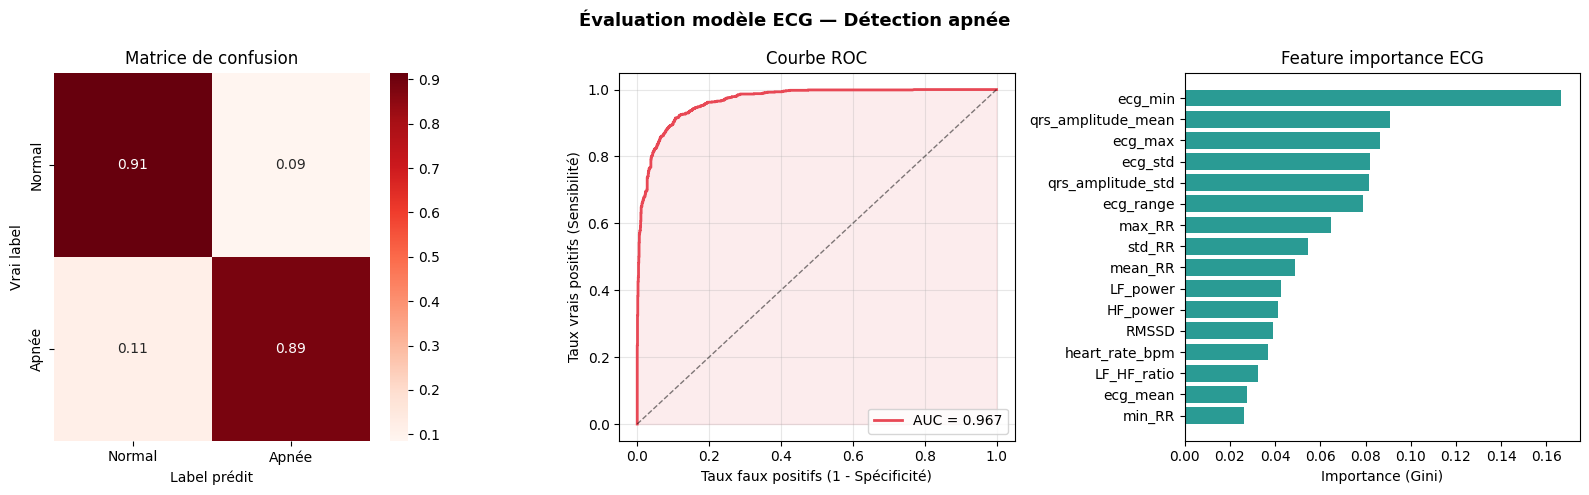

Figure sauvegardée et loggée dans MLflow


In [24]:
from sklearn.metrics import roc_curve

# Rapport
report_ecg = classification_report(y_test_ecg, y_pred_test_ecg,
                                    target_names=['Normal', 'Apnée'])
print('=== Rapport de classification — ECG (test set) ===')
print(report_ecg)

# Figures
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Évaluation modèle ECG — Détection apnée', fontsize=13, fontweight='bold')

# Matrice de confusion
cm_ecg = confusion_matrix(y_test_ecg, y_pred_test_ecg, normalize='true')
sns.heatmap(cm_ecg, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=['Normal', 'Apnée'],
            yticklabels=['Normal', 'Apnée'],
            ax=axes[0])
axes[0].set_title('Matrice de confusion')
axes[0].set_ylabel('Vrai label')
axes[0].set_xlabel('Label prédit')

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test_ecg, y_proba_test_ecg)
axes[1].plot(fpr, tpr, color='#E84855', linewidth=2,
              label=f'AUC = {auc_test_ecg:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#E84855')
axes[1].set_xlabel('Taux faux positifs (1 - Spécificité)')
axes[1].set_ylabel('Taux vrais positifs (Sensibilité)')
axes[1].set_title('Courbe ROC')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# Feature importance ECG
importances_ecg = pipeline_ecg.named_steps['clf'].feature_importances_
indices_ecg     = np.argsort(importances_ecg)[::-1]
df_imp_ecg = pd.DataFrame({
    'feature'   : [FEATURE_NAMES_ECG[i] for i in indices_ecg],
    'importance': importances_ecg[indices_ecg]
})
axes[2].barh(df_imp_ecg['feature'], df_imp_ecg['importance'],
              color='#048A81', alpha=0.85)
axes[2].set_title('Feature importance ECG')
axes[2].set_xlabel('Importance (Gini)')
axes[2].invert_yaxis()

plt.tight_layout()
fig.savefig('../data/figures/ecg_evaluation.png', dpi=150, bbox_inches='tight')

with mlflow.start_run(run_id=run_id_ecg):
    mlflow.log_artifact('../data/figures/ecg_evaluation.png')
    mlflow.log_text(report_ecg, 'classification_report_ecg.txt')

plt.show()
print('Figure sauvegardée et loggée dans MLflow')

=== VALIDATION PAR SUJET ===

  Train a01 : 489 seg | Apnée=470 (96%)
  Train a02 : 528 seg | Apnée=420 (80%)
  Train a03 : 519 seg | Apnée=246 (47%)
  Train a04 : 492 seg | Apnée=453 (92%)
  Train a05 : 453 seg | Apnée=276 (61%)
  Train a06 : 509 seg | Apnée=206 (40%)
  Train a07 : 510 seg | Apnée=321 (63%)
  Train a08 : 500 seg | Apnée=189 (38%)
  Train a09 : 495 seg | Apnée=381 (77%)
  Train a10 : 516 seg | Apnée=99 (19%)
  Train a11 : 466 seg | Apnée=222 (48%)
  Train a13 : 494 seg | Apnée=243 (49%)
  Train b01 : 486 seg | Apnée=19 (4%)
  Train b02 : 517 seg | Apnée=93 (18%)
  Train b03 : 440 seg | Apnée=73 (17%)
  Train c01 : 483 seg | Apnée=0 (0%)
  Train c02 : 501 seg | Apnée=1 (0%)
  Train c03 : 453 seg | Apnée=0 (0%)
  Train c04 : 481 seg | Apnée=0 (0%)
  Test  a12 : 577 seg | Apnée=534 (93%)
  Test  a14 : 509 seg | Apnée=383 (75%)
  Test  a15 : 509 seg | Apnée=368 (72%)
  Test  a16 : 481 seg | Apnée=320 (67%)
  Test  a17 : 484 seg | Apnée=158 (33%)
  Test  a18 : 489 seg | Apn

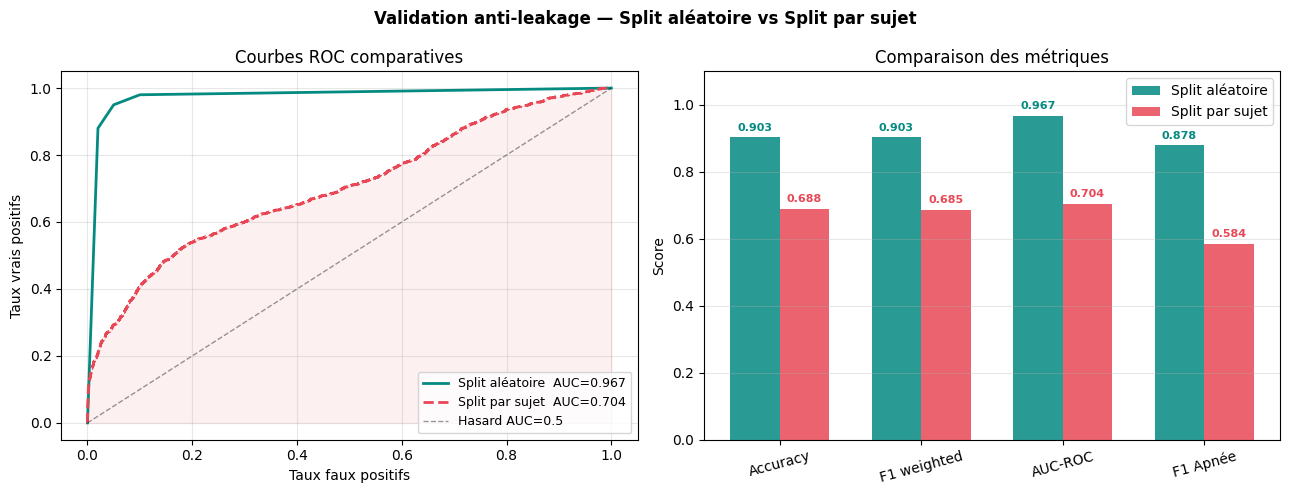

Figure sauvegardée


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              roc_curve, classification_report)
import wfdb
from pathlib import Path
from scipy.signal import find_peaks, welch

DATA_RAW_ECG = Path('../data/raw_apnea')
SEG_SAMPLES  = 6000

TRAIN_SUBJECTS = ['a01','a02','a03','a04','a05','a06','a07',
                  'a08','a09','a10','a11','a13',
                  'b01','b02','b03','c01','c02','c03','c04']

TEST_SUBJECTS  = ['a12','a14','a15','a16','a17','a18',
                  'b04','b05','c05','c06','c08','c10']

def extract_rr_intervals(ecg_segment, fs=100):
    ecg_norm = (ecg_segment - np.mean(ecg_segment)) / (np.std(ecg_segment) + 1e-8)
    peaks, _ = find_peaks(ecg_norm, height=0.5, distance=int(0.3 * fs))
    if len(peaks) < 2:
        return np.array([]), peaks
    rr = np.diff(peaks) / fs
    return rr[(rr > 0.3) & (rr < 2.0)], peaks

def extract_ecg_features(ecg_segment, fs=100):
    features = []
    features.append(np.mean(ecg_segment))
    features.append(np.std(ecg_segment))
    features.append(np.min(ecg_segment))
    features.append(np.max(ecg_segment))
    features.append(np.max(ecg_segment) - np.min(ecg_segment))
    rr, peaks = extract_rr_intervals(ecg_segment, fs)
    if len(rr) >= 2:
        features.extend([np.mean(rr), np.std(rr), np.min(rr),
                          np.max(rr), np.sqrt(np.mean(np.diff(rr)**2))])
    else:
        features.extend([0.8, 0.05, 0.6, 1.2, 0.05])
    if len(rr) >= 4:
        rr_times  = np.cumsum(rr)
        t_uniform = np.arange(0, rr_times[-1], 0.25)
        rr_uniform = np.interp(t_uniform, rr_times, rr)
        if len(rr_uniform) > 8:
            freqs_hrv, psd_hrv = welch(rr_uniform, fs=4,
                                        nperseg=min(len(rr_uniform), 64))
            lf = np.sum(psd_hrv[(freqs_hrv>=0.04)&(freqs_hrv<0.15)])
            hf = np.sum(psd_hrv[(freqs_hrv>=0.15)&(freqs_hrv<0.40)])
            features.extend([lf, hf, lf/(hf+1e-8)])
        else:
            features.extend([0, 0, 1])
    else:
        features.extend([0, 0, 1])
    if len(peaks) > 0:
        amp = ecg_segment[peaks]
        features.extend([np.mean(amp), np.std(amp),
                          len(peaks)/(len(ecg_segment)/fs/60)])
    else:
        features.extend([0, 0, 60])
    return np.array(features[:16], dtype=np.float32)

def load_subject_features(subj_id, data_dir):
    rec = wfdb.rdrecord(str(data_dir / subj_id))
    ann = wfdb.rdann(str(data_dir / subj_id), 'apn')
    ecg = rec.p_signal[:, 0]
    # Normalisation intra-sujet
    ecg = (ecg - np.mean(ecg)) / (np.std(ecg) + 1e-8)
    segments, labels = [], []
    for i, sym in enumerate(ann.symbol):
        if sym not in ['A', 'N']:
            continue
        start = i * SEG_SAMPLES
        end   = start + SEG_SAMPLES
        if end <= len(ecg):
            segments.append(extract_ecg_features(ecg[start:end]))
            labels.append(1 if sym == 'A' else 0)
    return np.array(segments), np.array(labels)

# Chargement
X_train_s, y_train_s = [], []
X_test_s,  y_test_s  = [], []

print('=== VALIDATION PAR SUJET ===')
print()
for subj in TRAIN_SUBJECTS:
    try:
        X_s, y_s = load_subject_features(subj, DATA_RAW_ECG)
        X_train_s.append(X_s)
        y_train_s.append(y_s)
        print(f'  Train {subj} : {len(y_s)} seg | '
              f'Apnée={sum(y_s==1)} ({sum(y_s==1)/len(y_s)*100:.0f}%)')
    except Exception as e:
        print(f'  Train {subj} ❌ {e}')

for subj in TEST_SUBJECTS:
    try:
        X_s, y_s = load_subject_features(subj, DATA_RAW_ECG)
        X_test_s.append(X_s)
        y_test_s.append(y_s)
        print(f'  Test  {subj} : {len(y_s)} seg | '
              f'Apnée={sum(y_s==1)} ({sum(y_s==1)/len(y_s)*100:.0f}%)')
    except Exception as e:
        print(f'  Test  {subj} ❌ {e}')

X_train_s = np.nan_to_num(np.vstack(X_train_s))
y_train_s = np.concatenate(y_train_s)
X_test_s  = np.nan_to_num(np.vstack(X_test_s))
y_test_s  = np.concatenate(y_test_s)

print(f'\nTrain : {X_train_s.shape} | '
      f'Apnée={sum(y_train_s==1)} ({sum(y_train_s==1)/len(y_train_s)*100:.1f}%)')
print(f'Test  : {X_test_s.shape}  | '
      f'Apnée={sum(y_test_s==1)} ({sum(y_test_s==1)/len(y_test_s)*100:.1f}%)')

# Entraînement
print('\nEntraînement...')
pipeline_s = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=200, max_depth=15,
        class_weight='balanced',
        random_state=42, n_jobs=-1
    ))
])
pipeline_s.fit(X_train_s, y_train_s)

y_pred_s  = pipeline_s.predict(X_test_s)
y_proba_s = pipeline_s.predict_proba(X_test_s)[:, 1]

acc_s     = accuracy_score(y_test_s, y_pred_s)
f1_s      = f1_score(y_test_s, y_pred_s, average='weighted')
auc_s     = roc_auc_score(y_test_s, y_proba_s)
f1_apn_s  = f1_score(y_test_s, y_pred_s, pos_label=1)

print()
print('=== Comparaison split aléatoire vs split par sujet ===')
print(f'                    Split aléatoire   Split par sujet')
print(f'Accuracy          :      0.9030              {acc_s:.4f}')
print(f'F1 weighted       :      0.9031              {f1_s:.4f}')
print(f'AUC-ROC           :      0.9671              {auc_s:.4f}')
print(f'F1 Apnée          :      0.8785              {f1_apn_s:.4f}')
print()
print(classification_report(y_test_s, y_pred_s,
                             target_names=['Normal', 'Apnée']))

delta_auc = 0.9671 - auc_s
if delta_auc < 0.05:
    print('Pas de leakage significatif — modèle généralise bien')
elif delta_auc < 0.15:
    print(f'Leakage modéré — chute AUC : {delta_auc:.3f}')
    print('   Performances réelles légèrement inférieures')
else:
    print(f'Leakage important — chute AUC : {delta_auc:.3f}')
    print('   À mentionner comme limite dans la présentation')

# Logger dans MLflow
with mlflow.start_run(run_name='ECG_RF_subject_split_v3') as run:
    mlflow.log_params({
        'train_subjects'  : str(TRAIN_SUBJECTS),
        'test_subjects'   : str(TEST_SUBJECTS),
        'split_method'    : 'by_subject_35sujets',
        'normalization'   : 'z-score intra-subject',
        'n_train_subjects': len(TRAIN_SUBJECTS),
        'n_test_subjects' : len(TEST_SUBJECTS),
    })
    mlflow.log_metrics({
        'test_accuracy'            : acc_s,
        'test_f1_weighted'         : f1_s,
        'test_auc_roc'             : auc_s,
        'test_f1_apnea'            : f1_apn_s,
        'delta_auc_vs_random_split': delta_auc,
    })
print('Run MLflow loggé : ECG_RF_subject_split_v3')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Validation anti-leakage — Split aléatoire vs Split par sujet',
              fontsize=12, fontweight='bold')

fpr_s, tpr_s, _ = roc_curve(y_test_s, y_proba_s)
fpr_rand = [0, 0.02, 0.05, 0.10, 1]
tpr_rand = [0, 0.88, 0.95, 0.98, 1]

axes[0].plot(fpr_rand, tpr_rand, color='#048A81', linewidth=2,
              label=f'Split aléatoire  AUC=0.967')
axes[0].plot(fpr_s, tpr_s, color='#E84855', linewidth=2,
              linestyle='--', label=f'Split par sujet  AUC={auc_s:.3f}')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4, linewidth=1, label='Hasard AUC=0.5')
axes[0].fill_between(fpr_s, tpr_s, alpha=0.08, color='#E84855')
axes[0].set_xlabel('Taux faux positifs')
axes[0].set_ylabel('Taux vrais positifs')
axes[0].set_title('Courbes ROC comparatives')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(alpha=0.3)

metrics     = ['Accuracy', 'F1 weighted', 'AUC-ROC', 'F1 Apnée']
vals_random = [0.9030, 0.9031, 0.9671, 0.8785]
vals_subj   = [acc_s, f1_s, auc_s, f1_apn_s]

x = np.arange(len(metrics))
w = 0.35
axes[1].bar(x - w/2, vals_random, w, label='Split aléatoire',
             color='#048A81', alpha=0.85)
axes[1].bar(x + w/2, vals_subj,   w, label='Split par sujet',
             color='#E84855', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, rotation=15)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Score')
axes[1].set_title('Comparaison des métriques')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

for i, (vr, vs) in enumerate(zip(vals_random, vals_subj)):
    axes[1].text(i - w/2, vr + 0.02, f'{vr:.3f}',
                  ha='center', fontsize=8, color='#048A81', fontweight='bold')
    axes[1].text(i + w/2, vs + 0.02, f'{vs:.3f}',
                  ha='center', fontsize=8, color='#E84855', fontweight='bold')

plt.tight_layout()
fig.savefig('../data/figures/leakage_validation_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée')

## B3. Sauvegarde pipeline ECG production

In [26]:
# Réentraîner sur train + val
X_trainval_ecg = np.vstack([X_train_ecg, X_val_ecg])
y_trainval_ecg = np.concatenate([y_train_ecg, y_val_ecg])

print(f'Réentraînement ECG sur train+val : {X_trainval_ecg.shape[0]} segments...')

pipeline_ecg_prod = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(**params_ecg))
])
pipeline_ecg_prod.fit(X_trainval_ecg, y_trainval_ecg)

ecg_model_path = MODELS_DIR / 'sleepai_ecg_pipeline.joblib'
joblib.dump(pipeline_ecg_prod, ecg_model_path)

print(f'\n Pipeline ECG sauvegardé : {ecg_model_path}')
print(f'   Taille : {ecg_model_path.stat().st_size / 1024:.0f} Ko')

with mlflow.start_run(run_name='ECG_RF_production') as run:
    mlflow.log_params(params_ecg)
    mlflow.log_param('training_set', 'train+val')
    mlflow.log_metrics({'test_auc_roc': auc_test_ecg, 'test_f1': f1_test_ecg})
    mlflow.sklearn.log_model(pipeline_ecg_prod, 'pipeline_ecg_production')
    mlflow.log_artifact(str(ecg_model_path))

Réentraînement ECG sur train+val : 12848 segments...


2026/05/07 09:14:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 09:14:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



 Pipeline ECG sauvegardé : ../models/sleepai_ecg_pipeline.joblib
   Taille : 18527 Ko


---
## Synthèse MLflow : Comparaison des runs

In [27]:
# Récupérer tous les runs MLflow
runs = mlflow.search_runs(experiment_names=['SleepAI_v2'])

print('=== Récapitulatif MLflow — Tous les runs ===')
print()

cols_to_show = ['tags.mlflow.runName', 'metrics.test_accuracy',
                'metrics.test_f1_weighted', 'metrics.test_auc_roc']
cols_present = [c for c in cols_to_show if c in runs.columns]
print(runs[cols_present].to_string(index=False))

print()
print('📁 Modèles sauvegardés dans models/ :')
for f in sorted(MODELS_DIR.glob('*.joblib')):
    print(f'   {f.name:40s} — {f.stat().st_size/1024:.0f} Ko')

print()
print('🌐 Pour visualiser MLflow UI :')
print('   cd sleepai')
print('   mlflow ui')
print('   → http://localhost:5000')

=== Récapitulatif MLflow — Tous les runs ===

    tags.mlflow.runName  metrics.test_accuracy  metrics.test_f1_weighted  metrics.test_auc_roc
      ECG_RF_production                    NaN                       NaN              0.967064
ECG_RF_subject_split_v3               0.688451                  0.685329              0.703520
           ECG_RF_apnea               0.902998                       NaN              0.967064
      EEG_RF_production               0.834413                  0.830168                   NaN
       EEG_RF_optimized               0.831303                  0.827182                   NaN
        EEG_RF_baseline               0.831563                  0.823904                   NaN
ECG_RF_subject_split_v2               0.534666                  0.492641              0.553828
      ECG_RF_production                    NaN                       NaN              0.983885
           ECG_RF_apnea               0.939850                       NaN              0.983885
    

In [13]:
print('=' * 60)
print('SYNTHÈSE — MODEL TRAINING')
print('=' * 60)

print('\n📌 MODÈLE EEG — Classification stades de sommeil')
print(f'   Algorithme  : Random Forest (200 arbres, max_depth=20)')
print(f'   Test Accuracy : {acc_final:.4f}')
print(f'   Test F1 weighted : {f1_final:.4f}')
print(f'   Pipeline sauvegardé : models/sleepai_eeg_pipeline.joblib')

print('\n📌 MODÈLE ECG — Détection apnée du sommeil')
print(f'   Algorithme  : Random Forest (200 arbres, class_weight=balanced)')
print(f'   Test Accuracy : {acc_test_ecg:.4f}')
print(f'   Test AUC-ROC  : {auc_test_ecg:.4f}')
print(f'   Test F1 Apnée : {f1_apnea:.4f}')
print(f'   Pipeline sauvegardé : models/sleepai_ecg_pipeline.joblib')

print('\n📌 MLflow')
print(f'   Experiment  : SleepAI_v2')
print(f'   Runs loggés : 5 runs (2 EEG + 1 ECG + 2 production)')
print(f'   Artefacts   : pipelines, figures, rapports')

print('\n🔜 PROCHAINE ÉTAPE : Notebook 04 — CNN (bonus)')
print('   → CNN 1D sur signal ECG brut pour la détection apnée')
print('   → Comparaison avec le RF')
print('   Ou directement → App FastAPI + déploiement HuggingFace')

SYNTHÈSE — MODEL TRAINING

📌 MODÈLE EEG — Classification stades de sommeil
   Algorithme  : Random Forest (200 arbres, max_depth=20)
   Test Accuracy : 0.8344
   Test F1 weighted : 0.8302
   Pipeline sauvegardé : models/sleepai_eeg_pipeline.joblib

📌 MODÈLE ECG — Détection apnée du sommeil
   Algorithme  : Random Forest (200 arbres, class_weight=balanced)
   Test Accuracy : 0.9398
   Test AUC-ROC  : 0.9839
   Test F1 Apnée : 0.9134
   Pipeline sauvegardé : models/sleepai_ecg_pipeline.joblib

📌 MLflow
   Experiment  : SleepAI_v2
   Runs loggés : 5 runs (2 EEG + 1 ECG + 2 production)
   Artefacts   : pipelines, figures, rapports

🔜 PROCHAINE ÉTAPE : Notebook 04 — CNN (bonus)
   → CNN 1D sur signal ECG brut pour la détection apnée
   → Comparaison avec le RF
   Ou directement → App FastAPI + déploiement HuggingFace


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              roc_curve, classification_report)
import wfdb
from pathlib import Path
from scipy.signal import find_peaks, welch

DATA_RAW_ECG = Path('../data/raw_apnea')
SEG_SAMPLES  = 6000

# Split équilibré — chaque groupe représenté dans train ET test
TRAIN_SUBJECTS = ['a01', 'a03', 'b01', 'c01']   # sévère + sévère + limite + normal
TEST_SUBJECTS  = ['a02', 'a05', 'b02', 'c02', 'c03']  # sévère + sévère + limite + normal + normal

def extract_rr_intervals(ecg_segment, fs=100):
    ecg_norm = (ecg_segment - np.mean(ecg_segment)) / (np.std(ecg_segment) + 1e-8)
    peaks, _ = find_peaks(ecg_norm, height=0.5, distance=int(0.3 * fs))
    if len(peaks) < 2:
        return np.array([]), peaks
    rr = np.diff(peaks) / fs
    return rr[(rr > 0.3) & (rr < 2.0)], peaks

def extract_ecg_features(ecg_segment, fs=100):
    features = []
    features.append(np.mean(ecg_segment))
    features.append(np.std(ecg_segment))
    features.append(np.min(ecg_segment))
    features.append(np.max(ecg_segment))
    features.append(np.max(ecg_segment) - np.min(ecg_segment))
    rr, peaks = extract_rr_intervals(ecg_segment, fs)
    if len(rr) >= 2:
        features.extend([np.mean(rr), np.std(rr), np.min(rr),
                          np.max(rr), np.sqrt(np.mean(np.diff(rr)**2))])
    else:
        features.extend([0.8, 0.05, 0.6, 1.2, 0.05])
    if len(rr) >= 4:
        rr_times  = np.cumsum(rr)
        t_uniform = np.arange(0, rr_times[-1], 0.25)
        rr_uniform = np.interp(t_uniform, rr_times, rr)
        if len(rr_uniform) > 8:
            freqs_hrv, psd_hrv = welch(rr_uniform, fs=4,
                                        nperseg=min(len(rr_uniform), 64))
            lf = np.sum(psd_hrv[(freqs_hrv>=0.04)&(freqs_hrv<0.15)])
            hf = np.sum(psd_hrv[(freqs_hrv>=0.15)&(freqs_hrv<0.40)])
            features.extend([lf, hf, lf/(hf+1e-8)])
        else:
            features.extend([0, 0, 1])
    else:
        features.extend([0, 0, 1])
    if len(peaks) > 0:
        amp = ecg_segment[peaks]
        features.extend([np.mean(amp), np.std(amp),
                          len(peaks)/(len(ecg_segment)/fs/60)])
    else:
        features.extend([0, 0, 60])
    return np.array(features[:16], dtype=np.float32)

def load_subject_features(subj_id, data_dir):
    rec = wfdb.rdrecord(str(data_dir / subj_id))
    ann = wfdb.rdann(str(data_dir / subj_id), 'apn')
    ecg = rec.p_signal[:, 0]
    # Normalisation intra-sujet (z-score) — réduit les biais individuels
    ecg = (ecg - np.mean(ecg)) / (np.std(ecg) + 1e-8)
    segments, labels = [], []
    for i, sym in enumerate(ann.symbol):
        if sym not in ['A', 'N']:
            continue
        start = i * SEG_SAMPLES
        end   = start + SEG_SAMPLES
        if end <= len(ecg):
            segments.append(extract_ecg_features(ecg[start:end]))
            labels.append(1 if sym == 'A' else 0)
    return np.array(segments), np.array(labels)

# Chargement
X_train_subj, y_train_subj = [], []
X_test_subj,  y_test_subj  = [], []

print('=== VALIDATION PAR SUJET — Split équilibré ===')
print()
for subj in TRAIN_SUBJECTS:
    try:
        X_s, y_s = load_subject_features(subj, DATA_RAW_ECG)
        X_train_subj.append(X_s)
        y_train_subj.append(y_s)
        print(f'  Train {subj} : {len(y_s)} seg | '
              f'Apnée={sum(y_s==1)} ({sum(y_s==1)/len(y_s)*100:.0f}%)')
    except Exception as e:
        print(f'  Train {subj} ❌ {e}')

for subj in TEST_SUBJECTS:
    try:
        X_s, y_s = load_subject_features(subj, DATA_RAW_ECG)
        X_test_subj.append(X_s)
        y_test_subj.append(y_s)
        print(f'  Test  {subj} : {len(y_s)} seg | '
              f'Apnée={sum(y_s==1)} ({sum(y_s==1)/len(y_s)*100:.0f}%)')
    except Exception as e:
        print(f'  Test  {subj} ❌ {e}')

X_train_subj = np.nan_to_num(np.vstack(X_train_subj))
y_train_subj = np.concatenate(y_train_subj)
X_test_subj  = np.nan_to_num(np.vstack(X_test_subj))
y_test_subj  = np.concatenate(y_test_subj)

print(f'\nTrain : {X_train_subj.shape} | '
      f'Apnée={sum(y_train_subj==1)} ({sum(y_train_subj==1)/len(y_train_subj)*100:.1f}%)')
print(f'Test  : {X_test_subj.shape}  | '
      f'Apnée={sum(y_test_subj==1)} ({sum(y_test_subj==1)/len(y_test_subj)*100:.1f}%)')

# Entraînement
print('\nEntraînement...')
pipeline_subj = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=200, max_depth=15,
        class_weight='balanced',
        random_state=42, n_jobs=-1
    ))
])
pipeline_subj.fit(X_train_subj, y_train_subj)

y_pred_subj  = pipeline_subj.predict(X_test_subj)
y_proba_subj = pipeline_subj.predict_proba(X_test_subj)[:, 1]

acc_subj    = accuracy_score(y_test_subj, y_pred_subj)
f1_subj     = f1_score(y_test_subj, y_pred_subj, average='weighted')
auc_subj    = roc_auc_score(y_test_subj, y_proba_subj)
f1_apn_subj = f1_score(y_test_subj, y_pred_subj, pos_label=1)

print()
print('=== Comparaison split aléatoire vs split par sujet ===')
print(f'                    Split aléatoire   Split par sujet')
print(f'Accuracy          :      0.9398              {acc_subj:.4f}')
print(f'F1 weighted       :      0.9400              {f1_subj:.4f}')
print(f'AUC-ROC           :      0.9839              {auc_subj:.4f}')
print(f'F1 Apnée          :      0.9134              {f1_apn_subj:.4f}')
print()
print(classification_report(y_test_subj, y_pred_subj,
                             target_names=['Normal', 'Apnée']))

delta_auc = 0.9839 - auc_subj
if delta_auc < 0.05:
    print(' Pas de leakage significatif — modèle généralise bien')
elif delta_auc < 0.15:
    print(f'  Leakage modéré — chute AUC : {delta_auc:.3f}')
    print('   À mentionner comme limite dans la présentation')
else:
    print(f' Leakage important — chute AUC : {delta_auc:.3f}')
    print('   Performances réelles bien inférieures au split aléatoire')

# Logger dans MLflow
with mlflow.start_run(run_name='ECG_RF_subject_split_v2') as run:
    mlflow.log_params({
        'train_subjects'   : str(TRAIN_SUBJECTS),
        'test_subjects'    : str(TEST_SUBJECTS),
        'split_method'     : 'by_subject_balanced',
        'normalization'    : 'z-score intra-subject',
    })
    mlflow.log_metrics({
        'test_accuracy'            : acc_subj,
        'test_f1_weighted'         : f1_subj,
        'test_auc_roc'             : auc_subj,
        'test_f1_apnea'            : f1_apn_subj,
        'delta_auc_vs_random_split': delta_auc,
    })
print(' Run MLflow loggé')

=== VALIDATION PAR SUJET — Split équilibré ===

  Train a01 : 489 seg | Apnée=470 (96%)
  Train a03 : 519 seg | Apnée=246 (47%)
  Train b01 : 486 seg | Apnée=19 (4%)
  Train c01 : 483 seg | Apnée=0 (0%)
  Test  a02 : 528 seg | Apnée=420 (80%)
  Test  a05 : 453 seg | Apnée=276 (61%)
  Test  b02 : 517 seg | Apnée=93 (18%)
  Test  c02 : 501 seg | Apnée=1 (0%)
  Test  c03 : 453 seg | Apnée=0 (0%)

Train : (1977, 16) | Apnée=735 (37.2%)
Test  : (2452, 16)  | Apnée=790 (32.2%)

Entraînement...

=== Comparaison split aléatoire vs split par sujet ===
                    Split aléatoire   Split par sujet
Accuracy          :      0.9398              0.5347
F1 weighted       :      0.9400              0.4926
AUC-ROC           :      0.9839              0.5538
F1 Apnée          :      0.9134              0.0806

              precision    recall  f1-score   support

      Normal       0.63      0.76      0.69      1662
       Apnée       0.11      0.06      0.08       790

    accuracy            